In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
ele_price = pd.read_excel('/Users/geng44/Desktop/project/Average_retail_price_of_electricity.xlsx')

ff_price = pd.read_excel('/Users/geng44/Desktop/project/Average_cost_of_fossil_fuels_for_electricity_generation.xlsx')

ff_receipt = pd.read_excel('/Users/geng44/Desktop/project/Receipts_of_fossil_fuels_by_electricity_plants_for_all_sectors.xlsx')

net_gene = pd.read_excel('/Users/geng44/Desktop/project/Net_generation.xlsx')

In [3]:
ele_price_T = ele_price.T
ele_price_T.columns = ele_price_T.iloc[0]
ele_price_T = ele_price_T[1:]

In [4]:
ff_price_T = ff_price.T
ff_price_T.columns = ff_price_T.iloc[0]
ff_price_T = ff_price_T[1:]

In [5]:
ff_receipt_T = ff_receipt.T
ff_receipt_T.columns = ff_receipt_T.iloc[0]
ff_receipt_T = ff_receipt_T[1:]

In [6]:
net_gene_T = net_gene.T
net_gene_T.columns = net_gene_T.iloc[0]
net_gene_T = net_gene_T[1:]
net_gene_T.fillna(0, inplace=True)

/var/folders/ty/9rmz2lcd2p35hd3wb4_5v6_m0000gs/T/ipykernel_73892/1080020301.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  net_gene_T.fillna(0, inplace=True)


In [7]:
ff_receipt_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,87608,37885,42373,5985,4965,628,639424
2008-02-01 00:00:00,84048,36201,41218,5406,3852,422,538625
2008-03-01 00:00:00,87826,39224,42789,4799,3721,630,563326
2008-04-01 00:00:00,86916,38415,42412,4898,6041,612,569441
2008-05-01 00:00:00,88716,40135,41773,5622,4102,516,575650
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,35625,11011,20918,3192,1527,127,1288923
2025-09-01 00:00:00,33684,11084,19635,2601,1039,84,1125996
2025-10-01 00:00:00,34535,11630,19754,2942,1154,133,971380
2025-11-01 00:00:00,33085,10884,18797,3031,1365,86,896400


In [8]:
ff_price_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,1.88,2.2,1.55,1.33,14.61,1.62,8.19
2008-02-01 00:00:00,1.89,2.22,1.55,1.37,15.03,1.82,8.58
2008-03-01 00:00:00,1.93,2.25,1.57,1.38,14.67,1.82,9.25
2008-04-01 00:00:00,1.97,2.33,1.57,1.42,14.65,1.79,9.89
2008-05-01 00:00:00,2.04,2.41,1.63,1.37,17.13,1.96,10.73
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,2.41,3.01,2.06,1.76,16.82,2.9,3.17
2025-09-01 00:00:00,2.41,2.97,2.03,1.94,16.25,2.73,3.04
2025-10-01 00:00:00,2.39,2.95,1.99,2.0,16.4,2.66,3.08
2025-11-01 00:00:00,2.39,2.92,2.03,2.08,16.46,2.51,3.89


In [9]:
ele_price_T

description,all sectors,residential,commercial,industrial,transportation,other
2001-01-01 00:00:00,6.75,7.73,7.25,4.73,NaN,6.48
2001-02-01 00:00:00,6.87,8.04,7.51,4.8,NaN,6.94
2001-03-01 00:00:00,7.01,8.32,7.7,4.86,NaN,7.05
2001-04-01 00:00:00,7.02,8.46,7.73,4.87,NaN,7.04
2001-05-01 00:00:00,7.17,8.83,7.77,5.0,NaN,7.14
...,...,...,...,...,...,...
2025-08-01 00:00:00,14.22,17.61,13.93,9.08,14.86,NaN
2025-09-01 00:00:00,14.21,18.08,13.99,9.02,15.25,NaN
2025-10-01 00:00:00,13.66,17.97,13.49,8.65,13.56,NaN
2025-11-01 00:00:00,13.43,17.78,13.19,8.44,13.64,NaN


In [10]:
net_gene_T

description,all fuels (utility-scale),coal,petroleum liquids,petroleum coke,natural gas,other gases,nuclear,conventional hydroelectric,other renewables,wind,all utility-scale solar,geothermal,biomass,wood and wood-derived fuels,other biomass,hydro-electric pumped storage,other,all solar,small-scale solar photovoltaic,all utility-scale solar
2008-01-01 00:00:00,362998.0,182876.0,3131.0,1366.0,72600.0,1063.0,70735.0,20779.0,0,4273.0,16.0,1209.0,4744.0,3338.0,1407.0,-746.0,951.0,0.0,0.0,16.0
2008-02-01 00:00:00,325106.0,166666.0,2438.0,1231.0,60042.0,972.0,65130.0,18789.0,0,3852.0,36.0,1087.0,4374.0,3010.0,1364.0,-451.0,939.0,0.0,0.0,36.0
2008-03-01 00:00:00,324630.0,160743.0,2112.0,1039.0,62171.0,1049.0,64716.0,21669.0,0,4782.0,75.0,1251.0,4596.0,3123.0,1472.0,-553.0,980.0,0.0,0.0,75.0
2008-04-01 00:00:00,305865.0,146983.0,2274.0,1126.0,63046.0,1021.0,57333.0,22234.0,0,5225.0,94.0,1218.0,4433.0,2930.0,1504.0,-132.0,1008.0,0.0,0.0,94.0
2008-05-01 00:00:00,325245.0,154916.0,2343.0,1055.0,62270.0,1044.0,64826.0,27221.0,0,5340.0,99.0,1259.0,4402.0,2927.0,1475.0,-587.0,1057.0,0.0,0.0,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01 00:00:00,420242.0,69728.0,1019.0,501.0,192894.0,864.0,70705.0,20098.0,0,27307.0,31809.0,1349.0,4037.0,2833.0,1204.0,-568.0,499.0,41128.0,9319.0,31809.0
2025-09-01 00:00:00,368145.0,58302.0,907.0,390.0,167876.0,963.0,65458.0,15285.0,0,25673.0,28149.0,1284.0,3849.0,2713.0,1136.0,-457.0,467.0,36325.0,8176.0,28149.0
2025-10-01 00:00:00,345253.0,54019.0,942.0,437.0,143985.0,1086.0,59222.0,16545.0,0,39534.0,24605.0,1267.0,3628.0,2467.0,1161.0,-513.0,497.0,32195.0,7589.0,24605.0
2025-11-01 00:00:00,334986.0,54490.0,981.0,334.0,131565.0,867.0,63809.0,18415.0,0,40957.0,18592.0,1263.0,3769.0,2581.0,1188.0,-610.0,554.0,24580.0,5987.0,18592.0


In [11]:
# natural gas generation share in electricity production
net_gene_T['ng_share'] = net_gene_T['natural gas']/net_gene_T['all fuels (utility-scale)']

In [12]:
# electricity price from cents per kwh to dollar per kwh
ele_price_T = ele_price_T/ 100

In [13]:
# fuel price from dollar per million Btu to dollar per kwh
ff_price_T = ff_price_T / 293.07 / 0.9

coef: -0.5551061985734218
intercept: 0.1413848862168
R^2: 0.05288489606355873


/Users/geng44/PycharmProjects/pythonProject/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


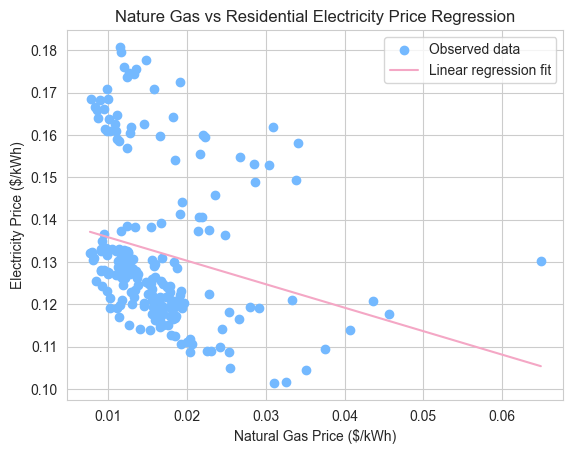

In [14]:
# linear regression
# ng price vs residential electricity price
df = pd.DataFrame({
    'natural_gas': ff_price_T['natural gas'],
    'residential_ele': ele_price_T['residential']
}).dropna()

X = df[['natural_gas']]
y = df['residential_ele']

model = LinearRegression()
model.fit(X, y)

print("coef:", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))

# scatter

plt.scatter(df['natural_gas'], df['residential_ele'], label='Observed data', color = "#74B9FF")

x_range = np.linspace(df['natural_gas'].min(), df['natural_gas'].max(), 100)

y_pred = model.predict(x_range.reshape(-1, 1))

# regression line

plt.plot(x_range, y_pred, color= "#F4A7C5", label='Linear regression fit')
plt.legend()

# labels

plt.xlabel('Natural Gas Price ($/kWh)')

plt.ylabel('Electricity Price ($/kWh)')

plt.title('Nature Gas vs Residential Electricity Price Regression')

plt.show()

coef: -0.18340443005747326
intercept: 0.11112749013137561
R^2: 0.01237747928905808


/Users/geng44/PycharmProjects/pythonProject/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


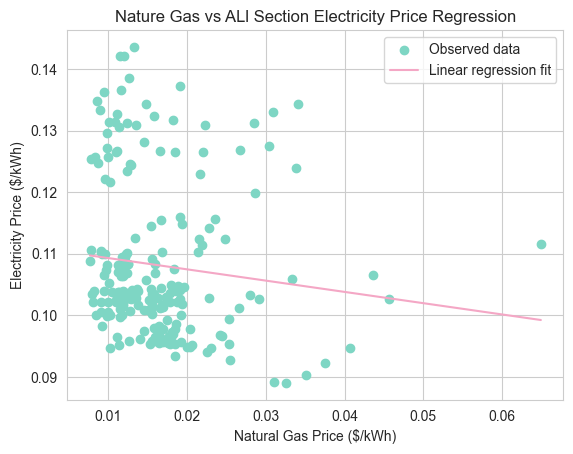

In [15]:
# linear regression
# ng price vs all section electricity price
df = pd.DataFrame({
    'natural_gas': ff_price_T['natural gas'],
    'all_ele': ele_price_T['all sectors']
}).dropna()

X = df[['natural_gas']]
y = df['all_ele']

model = LinearRegression()
model.fit(X, y)

print("coef:", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))

# scatter

plt.scatter(df['natural_gas'], df['all_ele'], label='Observed data', color = "#7ED6C4")

x_range = np.linspace(df['natural_gas'].min(), df['natural_gas'].max(), 100)

y_pred = model.predict(x_range.reshape(-1, 1))

# regression line

plt.plot(x_range, y_pred, color= "#F4A7C5", label='Linear regression fit')
plt.legend()

# labels

plt.xlabel('Natural Gas Price ($/kWh)')

plt.ylabel('Electricity Price ($/kWh)')

plt.title('Nature Gas vs ALl Section Electricity Price Regression')

plt.show()

/Users/geng44/PycharmProjects/pythonProject/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


coef: -0.08041307125907851
intercept: 0.11107052760494976
R^2: 0.0031751206346761762


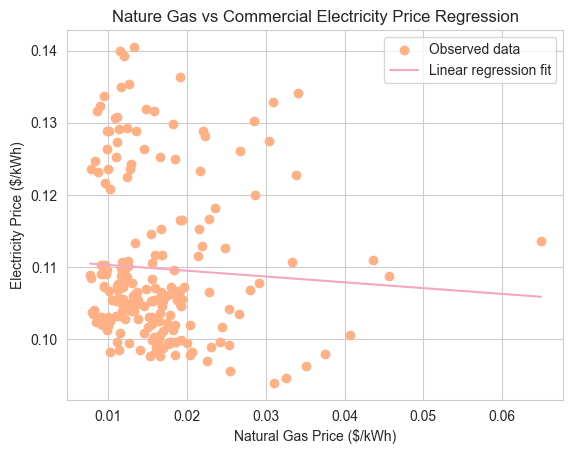

In [16]:
# linear regression
# ng price vs Commercial electricity price
df = pd.DataFrame({
    'natural_gas': ff_price_T['natural gas'],
    'commercial_ele': ele_price_T['commercial']
}).dropna()

X = df[['natural_gas']]
y = df['commercial_ele']

model = LinearRegression()
model.fit(X, y)

print("coef:", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))

# scatter

plt.scatter(df['natural_gas'], df['commercial_ele'], label='Observed data', color = "#FFB085")

x_range = np.linspace(df['natural_gas'].min(), df['natural_gas'].max(), 100)

y_pred = model.predict(x_range.reshape(-1, 1))

# regression line

plt.plot(x_range, y_pred, color= "#F4A7C5", label='Linear regression fit')
plt.legend()

# labels

plt.xlabel('Natural Gas Price ($/kWh)')

plt.ylabel('Electricity Price ($/kWh)')

plt.title('Nature Gas vs Commercial Electricity Price Regression')

plt.show()

coef: 0.11469265606468314
intercept: 0.06984402983898337
R^2: 0.015003347532835942


/Users/geng44/PycharmProjects/pythonProject/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


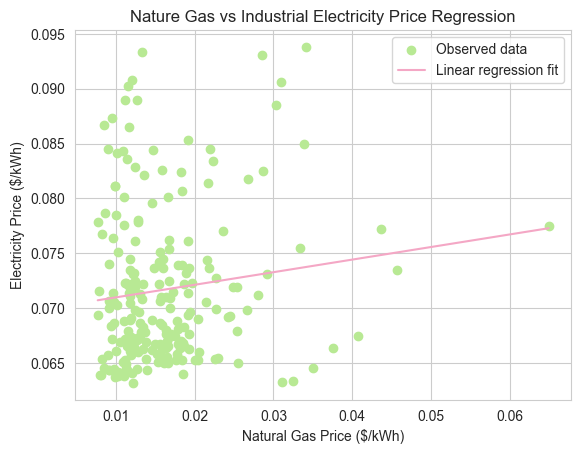

In [17]:
# linear regression
# ng price vs Industrial electricity price
df = pd.DataFrame({
    'natural_gas': ff_price_T['natural gas'],
    'industrial_ele': ele_price_T['industrial']
}).dropna()

X = df[['natural_gas']]
y = df['industrial_ele']

model = LinearRegression()
model.fit(X, y)

print("coef:", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))

# scatter

plt.scatter(df['natural_gas'], df['industrial_ele'], label='Observed data', color = "#B8E994")

x_range = np.linspace(df['natural_gas'].min(), df['natural_gas'].max(), 100)

y_pred = model.predict(x_range.reshape(-1, 1))

# regression line

plt.plot(x_range, y_pred, color= "#F4A7C5", label='Linear regression fit')
plt.legend()

# labels

plt.xlabel('Natural Gas Price ($/kWh)')

plt.ylabel('Electricity Price ($/kWh)')

plt.title('Nature Gas vs Industrial Electricity Price Regression')

plt.show()

coef: 0.12216204959211982
intercept: 0.10546953723256308
R^2: 0.005292575076360717


/Users/geng44/PycharmProjects/pythonProject/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


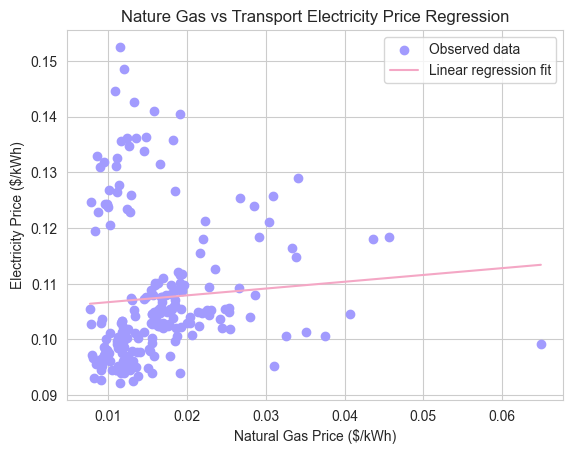

In [18]:
# linear regression
# ng price vs Transport electricity price
df = pd.DataFrame({
    'natural_gas': ff_price_T['natural gas'],
    'transport_ele': ele_price_T['transportation']
}).dropna()

X = df[['natural_gas']]
y = df['transport_ele']

model = LinearRegression()
model.fit(X, y)

print("coef:", model.coef_[0])
print("intercept:", model.intercept_)
print("R^2:", model.score(X, y))

# scatter
plt.scatter(df['natural_gas'], df['transport_ele'], label='Observed data', color = "#A29BFE")
x_range = np.linspace(df['natural_gas'].min(), df['natural_gas'].max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))

# regression line
plt.plot(x_range, y_pred, color= "#F4A7C5", label='Linear regression fit')
plt.legend()

# labels
plt.xlabel('Natural Gas Price ($/kWh)')
plt.ylabel('Electricity Price ($/kWh)')
plt.title('Nature Gas vs Transport Electricity Price Regression')
plt.show()

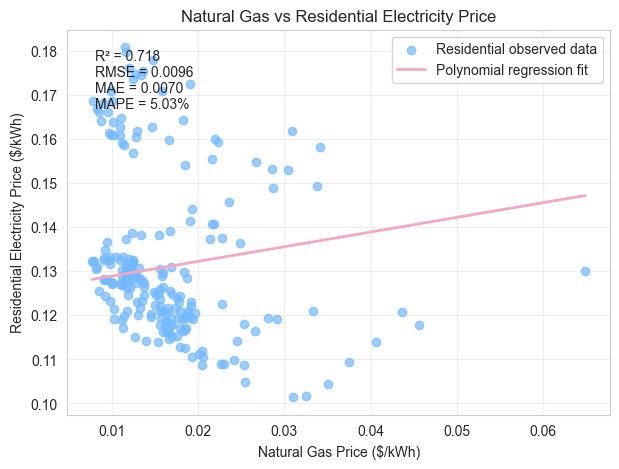

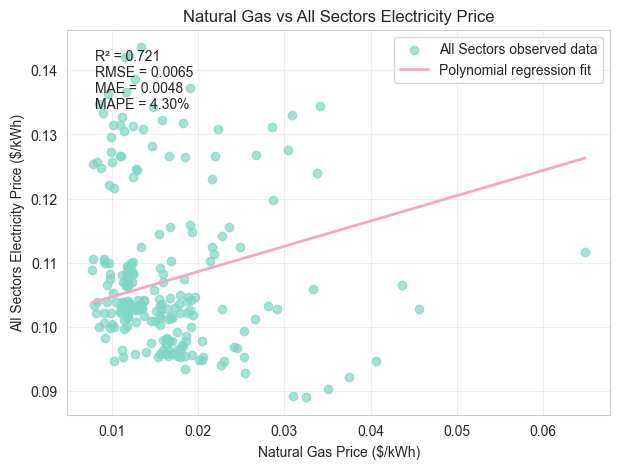

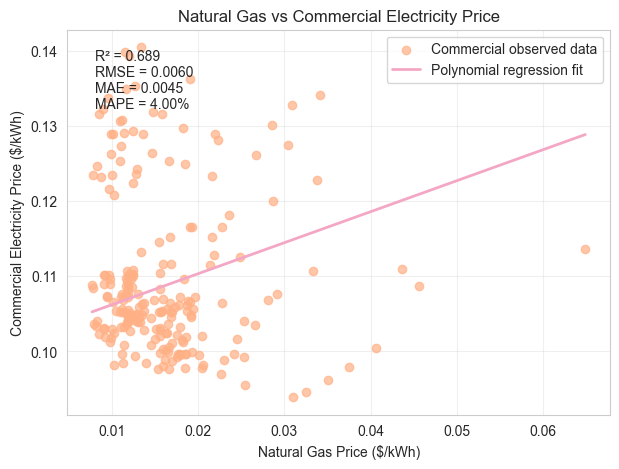

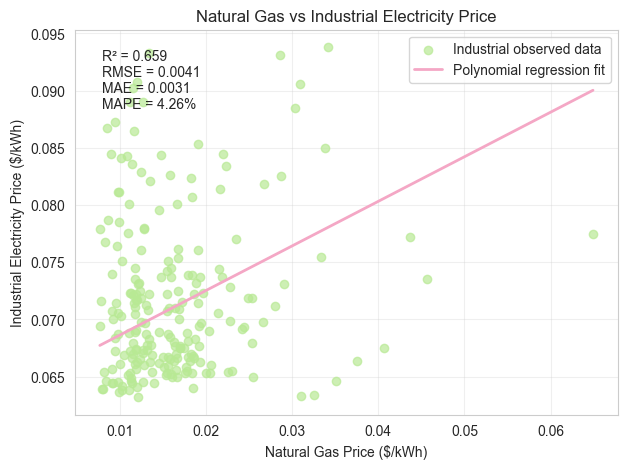

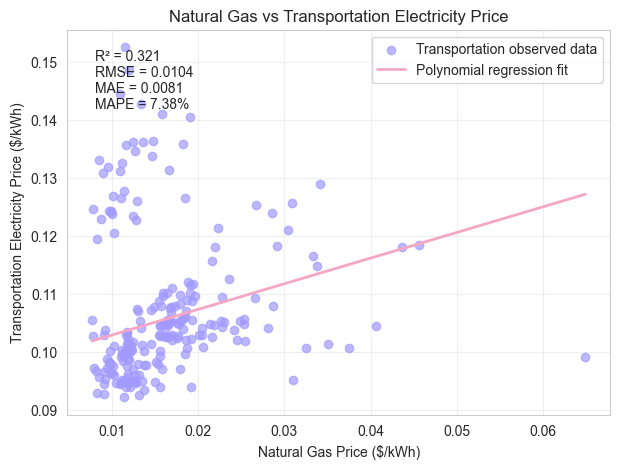

,Sector,RMSE,MAE,MAPE (%),R2
0,Residential,0.009601,0.006972,5.027679,0.718030
1,All Sectors,0.006526,0.004820,4.301428,0.720686
2,Commercial,0.005961,0.004514,4.000038,0.689053
3,Industrial,0.004098,0.003109,4.263394,0.658522
4,Transportation,0.010367,0.008112,7.383284,0.320571


In [19]:
# sectors and colors
sector_info = {
    'residential': {
        'column_name': 'residential_ele',
        'color': '#74B9FF',
        'label': 'Residential'
    },

    'all sectors': {
        'column_name': 'all_ele',
        'color': '#7ED6C4',
        'label': 'All Sectors'
    },

    'commercial': {
        'column_name': 'commercial_ele',
        'color': '#FFB085',
        'label': 'Commercial'
    },

    'industrial': {
        'column_name': 'industrial_ele',
        'color': '#B8E994',
        'label': 'Industrial'
    },

    'transportation': {
        'column_name': 'transport_ele',
        'color': '#A29BFE',
        'label': 'Transportation'
    }

}

results = []

# polynomial regression for each sector
for sector, info in sector_info.items():
    df = pd.DataFrame({
        'gas_price': ff_price_T['natural gas'],
        'ng_share': net_gene_T['ng_share'],
        'gas_receipt': ff_receipt_T['natural gas'],
        'ele_price': ele_price_T[sector]
    }).dropna()

    X = df[['gas_price', 'ng_share', 'gas_receipt']]
    y = df['ele_price']

    model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LinearRegression()
    )

    model.fit(X, y)
    y_pred = model.predict(X)

    # metrics
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / (y + 1e-6))) * 100
    r2 = r2_score(y, y_pred)

    results.append({
        'Sector': info['label'],
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2
    })

    # partial effect plot
    x_range = np.linspace(df['gas_price'].min(), df['gas_price'].max(), 100)
    X_plot = pd.DataFrame({
        'gas_price': x_range,
        'ng_share': df['ng_share'].mean(),
        'gas_receipt': df['gas_receipt'].mean()
    })

    y_plot = model.predict(X_plot)

    plt.figure(figsize=(7, 5))
    plt.scatter(
        df['gas_price'],
        df['ele_price'],
        label=f'{info["label"]} observed data',
        color=info['color'],
        alpha=0.7
    )

    plt.plot(
        x_range,
        y_plot,
        color='#F4A7C5',
        linewidth=2,
        label='Polynomial regression fit'
    )

    plt.xlabel('Natural Gas Price ($/kWh)')
    plt.ylabel(f'{info["label"]} Electricity Price ($/kWh)')
    plt.title(f'Natural Gas vs {info["label"]} Electricity Price')

    plt.text(
        0.05, 0.95,
        f'R² = {r2:.3f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}\nMAPE = {mape:.2f}%',
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# metrics table
results_df = pd.DataFrame(results)
results_df

In [24]:
df_corr = pd.DataFrame({
    'gas_price': ff_price_T['natural gas'],
    'all_ele': ele_price_T['all sectors'],
    'residential_ele': ele_price_T['residential'],
    'commercial_ele': ele_price_T['commercial'],
    'industrial_ele': ele_price_T['industrial'],
    'transport_ele': ele_price_T['transportation']
}).dropna()

corr_matrix = df_corr.corr()
print(corr_matrix)

                 gas_price   all_ele  residential_ele  commercial_ele  \
gas_price         1.000000 -0.111254        -0.229967       -0.056348   
all_ele          -0.111254  1.000000         0.968915        0.994062   
residential_ele  -0.229967  0.968915         1.000000        0.959584   
commercial_ele   -0.056348  0.994062         0.959584        1.000000   
industrial_ele    0.122488  0.934820         0.842564        0.947601   
transport_ele     0.072750  0.842344         0.788588        0.860041   

                 industrial_ele  transport_ele  
gas_price              0.122488       0.072750  
all_ele                0.934820       0.842344  
residential_ele        0.842564       0.788588  
commercial_ele         0.947601       0.860041  
industrial_ele         1.000000       0.860254  
transport_ele          0.860254       1.000000  


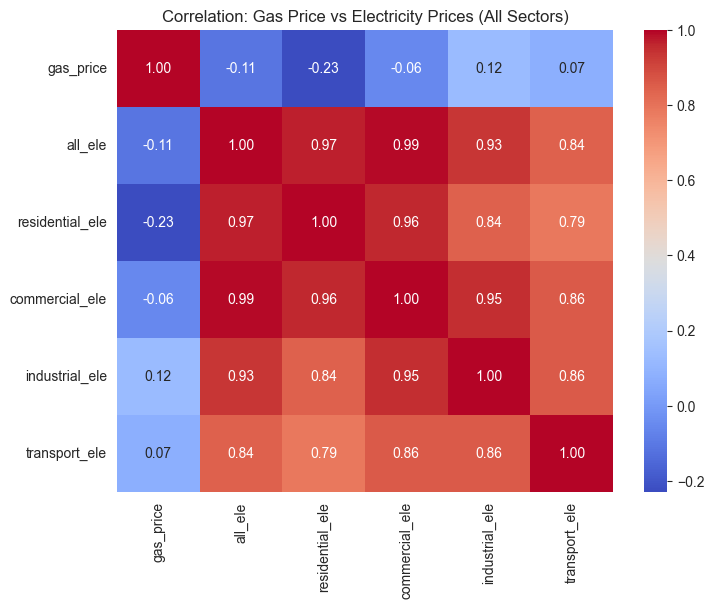

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation: Gas Price vs Electricity Prices (All Sectors)")
plt.show()

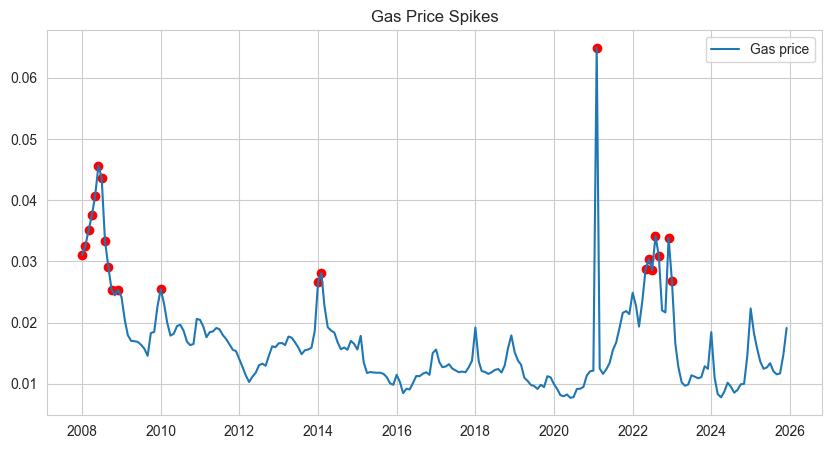

In [27]:
threshold = df_corr['gas_price'].quantile(0.9)
spike_periods = df_corr[df_corr['gas_price'] > threshold]
plt.figure(figsize=(10,5))
plt.plot(df_corr.index, df_corr['gas_price'], label='Gas price')
plt.scatter(spike_periods.index, spike_periods['gas_price'], color='red')
plt.title("Gas Price Spikes")
plt.legend()
plt.show()

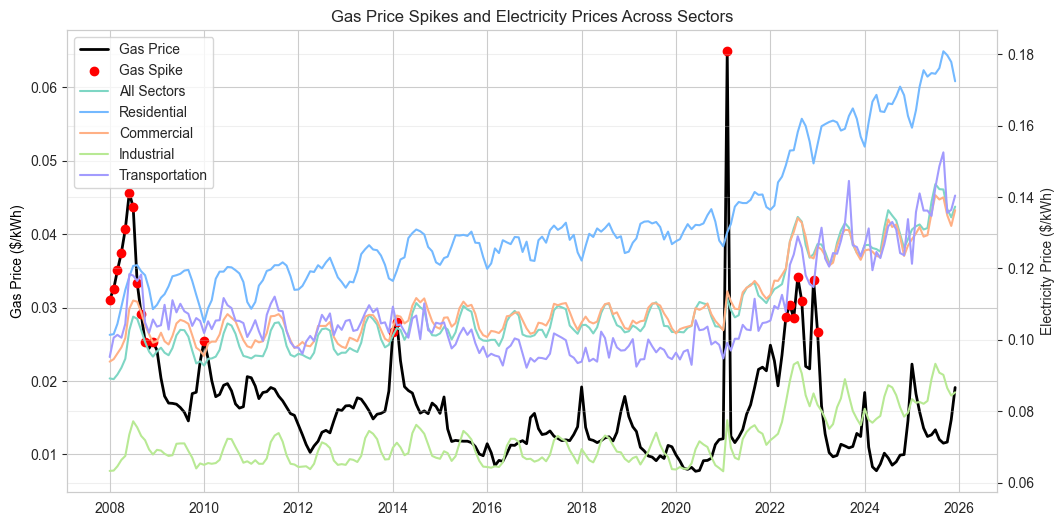

In [29]:
threshold = df_corr['gas_price'].quantile(0.9)
spike_periods = df_corr[df_corr['gas_price'] > threshold]

plt.figure(figsize=(12,6))

ax1 = plt.gca()

ax1.plot(
    df_corr.index,
    df_corr['gas_price'],
    label='Gas Price',
    color='black',
    linewidth=2
)

ax1.scatter(
    spike_periods.index,
    spike_periods['gas_price'],
    color='red',
    label='Gas Spike',
    zorder=3
)

ax1.set_ylabel('Gas Price ($/kWh)', color='black')

ax2 = ax1.twinx()

ax2.plot(df_corr.index, df_corr['all_ele'], label='All Sectors', color='#7ED6C4')
ax2.plot(df_corr.index, df_corr['residential_ele'], label='Residential', color='#74B9FF')
ax2.plot(df_corr.index, df_corr['commercial_ele'], label='Commercial', color='#FFB085')
ax2.plot(df_corr.index, df_corr['industrial_ele'], label='Industrial', color='#B8E994')
ax2.plot(df_corr.index, df_corr['transport_ele'], label='Transportation', color='#A29BFE')

ax2.set_ylabel('Electricity Price ($/kWh)')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title("Gas Price Spikes and Electricity Prices Across Sectors")
plt.grid(alpha=0.3)

plt.show()